In [1]:
import sys
# הסרה והתקנה נקייה למניעת התנגשויות
%pip uninstall ultralytics -y
%pip install ultralytics

import os
import shutil
import random
import glob
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from ultralytics import YOLO
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# הגדרת הגרף שייראה טוב
%matplotlib inline

print("✅ Libraries loaded successfully.")

Found existing installation: ultralytics 8.3.240
Uninstalling ultralytics-8.3.240:
  Successfully uninstalled ultralytics-8.3.240
Note: you may need to restart the kernel to use updated packages.
  Using cached ultralytics-8.3.246-py3-none-any.whl.metadata (37 kB)
Using cached ultralytics-8.3.246-py3-none-any.whl (1.2 MB)
Note: you may need to restart the kernel to use updated packages.
✅ Libraries loaded successfully.


In [2]:
# --- הגדרות נתיבים ---
base_project_path = r"C:\Users\yuval\PycharmProjects\GenAI_Project"

# 1. נתיבי המקור (הנתונים הגולמיים כפי שהם עכשיו)
source_dirs = {
    'mud': {
        'images': os.path.join(base_project_path, "dirty_imgs", "mud", "image_dirty"),
        'labels': os.path.join(base_project_path, "dirty_imgs", "mud", "label_2")
    },
    'water': {
        'images': os.path.join(base_project_path, "dirty_imgs", "water", "image_dirty"),
        'labels': os.path.join(base_project_path, "dirty_imgs", "water", "label_2")
    }
}

# 2. נתיב היעד (התיקייה החדשה שתיווצר עבור YOLO)
output_dir = os.path.join(base_project_path, "yolo_dataset_final")

print(f"📂 Source Data: {base_project_path}\\dirty_imgs")
print(f"📂 Target Dataset: {output_dir}")

# בדיקת תקינות
if not os.path.exists(source_dirs['mud']['images']):
    raise FileNotFoundError("❌ Error: Could not find source images. Check path!")

📂 Source Data: C:\Users\yuval\PycharmProjects\GenAI_Project\dirty_imgs
📂 Target Dataset: C:\Users\yuval\PycharmProjects\GenAI_Project\yolo_dataset_final


In [3]:
def convert_kitti_to_yolo(kitti_path, img_w, img_h):
    """Converts KITTI label format to YOLO format"""
    yolo_lines = []
    if not os.path.exists(kitti_path): return []

    with open(kitti_path, 'r') as f:
        for line in f.readlines():
            parts = line.split()
            if len(parts) < 15 or parts[0] == 'DontCare': continue

            try:
                # KITTI bbox: left, top, right, bottom
                l, t, r, b = map(float, parts[4:8])

                # Normalize to 0-1 (x_center, y_center, width, height)
                xc = (l + r) / 2.0 / img_w
                yc = (t + b) / 2.0 / img_h
                w = (r - l) / img_w
                h = (b - t) / img_h

                # Class ID 0 for all contamination types
                yolo_lines.append(f"0 {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}")
            except ValueError:
                continue
    return yolo_lines

def prepare_dataset(source_dirs, output_dir, split_ratios=(0.7, 0.2, 0.1)):
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir) # Clean start

    # Create directories
    for split in ['train', 'val', 'test']:
        os.makedirs(os.path.join(output_dir, "images", split), exist_ok=True)
        os.makedirs(os.path.join(output_dir, "labels", split), exist_ok=True)

    print("🚀 Processing images and labels...")
    counts = {'train': 0, 'val': 0, 'test': 0}

    for category, paths in source_dirs.items():
        img_src = paths['images']
        lbl_src = paths['labels']

        files = [f for f in os.listdir(img_src) if f.endswith(('.png', '.jpg'))]
        random.seed(42) # Ensure reproducibility
        random.shuffle(files)

        # Split logic
        n = len(files)
        train_end = int(n * split_ratios[0])
        val_end = train_end + int(n * split_ratios[1])

        splits = {
            'train': files[:train_end],
            'val': files[train_end:val_end],
            'test': files[val_end:]
        }

        for split_name, file_list in splits.items():
            for filename in tqdm(file_list, desc=f"{category} -> {split_name}", leave=False):
                # Paths
                src_img_path = os.path.join(img_src, filename)
                src_txt_path = os.path.join(lbl_src, filename.replace('.png', '.txt').replace('.jpg', '.txt'))

                new_name = f"{category}_{filename}"
                dst_img_path = os.path.join(output_dir, "images", split_name, new_name)
                dst_txt_path = os.path.join(output_dir, "labels", split_name, new_name.replace('.png', '.txt'))

                # Copy Image
                shutil.copy(src_img_path, dst_img_path)

                # Convert Label
                try:
                    with Image.open(src_img_path) as img:
                        w, h = img.size

                    if os.path.exists(src_txt_path):
                        yolo_labels = convert_kitti_to_yolo(src_txt_path, w, h)
                        if yolo_labels:
                            with open(dst_txt_path, 'w') as f:
                                f.write("\n".join(yolo_labels))
                            counts[split_name] += 1
                except Exception as e:
                    print(f"Error: {e}")

    print(f"\n✅ Dataset Ready! Counts (Labeled images): {counts}")
    return output_dir

# Run the preparation
prepare_dataset(source_dirs, output_dir)

🚀 Processing images and labels...



✅ Dataset Ready! Counts (Labeled images): {'train': 4736, 'val': 1352, 'test': 678}


'C:\\Users\\yuval\\PycharmProjects\\GenAI_Project\\yolo_dataset_final'

In [4]:
# Create YAML config
yaml_content = f"""
path: {output_dir.replace(os.sep, '/')}
train: images/train
val: images/val
test: images/test

nc: 1
names: ['contamination']
"""

yaml_path = os.path.join(output_dir, "custom_data.yaml")
with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(f"📄 YAML saved to: {yaml_path}")

📄 YAML saved to: C:\Users\yuval\PycharmProjects\GenAI_Project\yolo_dataset_final\custom_data.yaml


In [5]:
# Load a pretrained model (Transfer Learning)
trained_model = YOLO("yolov8n.pt")

print("\n🏋️ Starting Training...")
results = trained_model.train(
    data=yaml_path,
    epochs=25,
    imgsz=640,
    batch=16,
    name="dirt_detection_trained",
    patience=10,
    device=0, # Use GPU
    verbose=True
)
print("✅ Training Complete.")


🏋️ Starting Training...
Ultralytics 8.3.246  Python-3.12.9 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\yuval\PycharmProjects\GenAI_Project\yolo_dataset_final\custom_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=dirt_detection_trained, nbs=64, nms=False

In [ ]:

print("\n🤖 Loading Baseline Model (Not Trained on your data)...")
# טוענים מחדש מודל נקי
baseline_model = YOLO("yolov8n.pt")

# מריצים הערכה (Validation) על ה-Test Set
# שים לב: המודל הזה אומן על COCO (אנשים, מכוניות וכו') ולא על בוץ.
# אנחנו מצפים ל-mAP נמוך מאוד או 0.
print("Running Baseline Evaluation on Test Set...")
baseline_metrics = baseline_model.val(data=yaml_path, split='test', name="baseline_eval")

print(f"\n--- Comparison Results ---")
print(f"Baseline Model mAP50: {baseline_metrics.box.map50:.4f}")
print(f"(Expected to be near 0 because it doesn't know what 'contamination' is)")

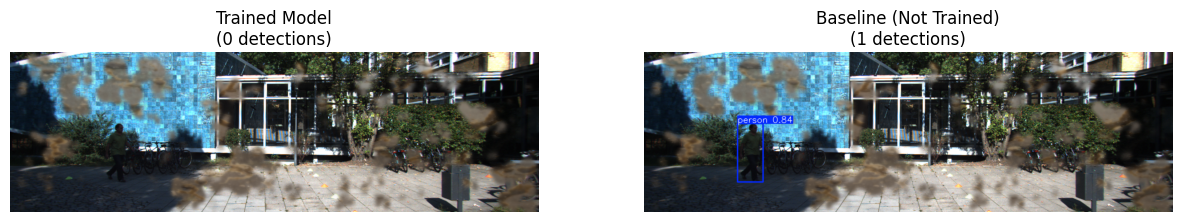

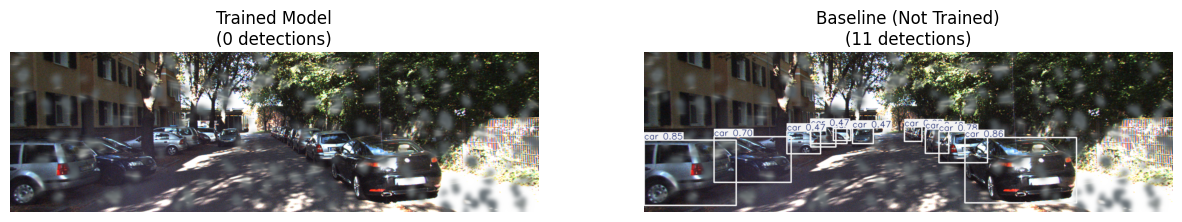

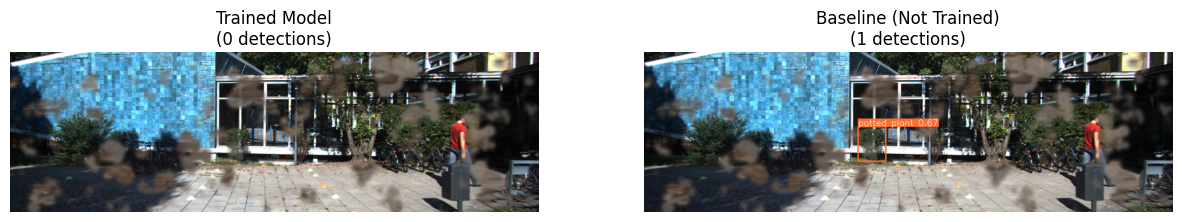

In [7]:
# בוחרים 3 תמונות אקראיות מסט הטסט
test_images_path = os.path.join(output_dir, "images", "test")
all_test_files = glob.glob(os.path.join(test_images_path, "*.png"))
sample_images = random.sample(all_test_files, 3)

for img_path in sample_images:
    # 1. חיזוי עם המודל המאומן
    res_trained = trained_model.predict(img_path, conf=0.25, verbose=False)[0]

    # 2. חיזוי עם המודל הבסיסי (הלא מאומן)
    res_baseline = baseline_model.predict(img_path, conf=0.25, verbose=False)[0]

    # 3. הצגה
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # תמונה שמאלית - מאומן
    axes[0].imshow(res_trained.plot()[..., ::-1]) # המרה מ-BGR ל-RGB
    axes[0].set_title(f"Trained Model\n({len(res_trained.boxes)} detections)")
    axes[0].axis('off')

    # תמונה ימנית - לא מאומן
    axes[1].imshow(res_baseline.plot()[..., ::-1])
    axes[1].set_title(f"Baseline (Not Trained)\n({len(res_baseline.boxes)} detections)")
    axes[1].axis('off')

    plt.show()

In [8]:
import os
import shutil
from PIL import Image

# --- הגדרות ---
base_project_path = r"C:\Users\yuval\PycharmProjects\GenAI_Project"

# 1. הגדר כאן את הנתיב לתמונות *הנקיות* ולתוויות שלהן
# (זה הנתיב שבו שמרת את הדאטה המקורי לפני הג'נרציה)
source_clean_images = r"C:\Users\yuval\.cache\kagglehub\datasets\klemenko\kitti-dataset\versions\1\data_object_image_2\testing\image_2" # <--- שנה לנתיב האמיתי!
source_clean_labels = r"C:\Users\yuval\.cache\kagglehub\datasets\klemenko\kitti-dataset\versions\1\data_object_calib\testing\calib" # <--- שנה לנתיב האמיתי!

# בדיקת בטיחות: אם לא שינית את הנתיב, נזרוק שגיאה כדי שלא תריץ סתם
if "Path\To" in source_clean_images:
    raise ValueError("⚠️ עצור! עליך לעדכן את המשתנה source_clean_images לנתיב התמונות הנקיות שלך.")

# 2. נתיב היעד שייווצר (אין צורך לשנות)
clean_output_dir = os.path.join(base_project_path, "yolo_dataset_clean_test")

# ניקוי והכנה מחדש
if os.path.exists(clean_output_dir):
    shutil.rmtree(clean_output_dir)

os.makedirs(os.path.join(clean_output_dir, "images/test"), exist_ok=True)
os.makedirs(os.path.join(clean_output_dir, "labels/test"), exist_ok=True)

print(f"🚀 Preparing Clean Test Set from: {source_clean_images}")

# מעתיקים כמות קטנה לבדיקה (למשל 50 תמונות)
# וודא שיש לך לפחות 50 תמונות בתיקייה הנקייה
clean_files = [f for f in os.listdir(source_clean_images) if f.endswith('.png')][:50]

count = 0
for filename in clean_files:
    src_img = os.path.join(source_clean_images, filename)
    src_txt = os.path.join(source_clean_labels, filename.replace('.png', '.txt'))

    dst_img = os.path.join(clean_output_dir, "images/test", filename)
    dst_txt = os.path.join(clean_output_dir, "labels/test", filename.replace('.png', '.txt'))

    # העתקת התמונה
    shutil.copy(src_img, dst_img)

    # המרה ל-YOLO
    if os.path.exists(src_txt):
        try:
            with Image.open(src_img) as img:
                w, h = img.size
            yolo_lbl = convert_kitti_to_yolo(src_txt, w, h) # משתמש בפונקציה שהגדרנו בתאים קודמים
            if yolo_lbl:
                with open(dst_txt, 'w') as f:
                    f.write("\n".join(yolo_lbl))
                count += 1
        except Exception as e:
            print(f"Error processing {filename}: {e}")

print(f"✅ Processed {count} clean images.")

# יצירת YAML לנקי
clean_yaml_content = f"""
path: {clean_output_dir.replace(os.sep, '/')}
train: images/test
val: images/test
test: images/test

nc: 1
names: ['object']
"""
clean_yaml_path = os.path.join(clean_output_dir, "clean_data.yaml")
with open(clean_yaml_path, "w") as f:
    f.write(clean_yaml_content)

print(f"✅ Clean dataset ready. YAML at: {clean_yaml_path}")

<>:14: SyntaxWarning: invalid escape sequence '\T'
<>:14: SyntaxWarning: invalid escape sequence '\T'
C:\Users\yuval\AppData\Local\Temp\ipykernel_20652\1369057710.py:14: SyntaxWarning: invalid escape sequence '\T'
  if "Path\To" in source_clean_images:


🚀 Preparing Clean Test Set from: C:\Users\yuval\.cache\kagglehub\datasets\klemenko\kitti-dataset\versions\1\data_object_image_2\testing\image_2
✅ Processed 0 clean images.
✅ Clean dataset ready. YAML at: C:\Users\yuval\PycharmProjects\GenAI_Project\yolo_dataset_clean_test\clean_data.yaml


In [9]:
print("\n📊 Running Comprehensive KPI Evaluation (This may take a minute)...")

# 1. Baseline Model on Clean Data (המצב האידיאלי)
# מודל רגיל על תמונות נקיות - לראות מה המקסימום האפשרי
print("1/4 Testing: Baseline Model on CLEAN Data...")
metrics_base_clean = baseline_model.val(data=clean_yaml_path, split='test', verbose=False)
map_base_clean = metrics_base_clean.box.map50

# 2. Baseline Model on Dirty Data (הבעיה)
# כמה הביצועים צנחו בגלל הלכלוך?
print("2/4 Testing: Baseline Model on DIRTY Data...")
metrics_base_dirty = baseline_model.val(data=yaml_path, split='test', verbose=False)
map_base_dirty = metrics_base_dirty.box.map50

# 3. Trained Model on Dirty Data (הפתרון שלנו)
# כמה הצלחנו לשפר?
print("3/4 Testing: Our Trained Model on DIRTY Data...")
metrics_trained_dirty = trained_model.val(data=yaml_path, split='test', verbose=False)
map_trained_dirty = metrics_trained_dirty.box.map50

# 4. Trained Model on Clean Data (בקרת איכות)
# האם הרסנו את היכולת לזהות מכוניות נקיות?
print("4/4 Testing: Our Trained Model on CLEAN Data...")
metrics_trained_clean = trained_model.val(data=clean_yaml_path, split='test', verbose=False)
map_trained_clean = metrics_trained_clean.box.map50

print("\n✅ Evaluation Done. Generating Report...")


📊 Running Comprehensive KPI Evaluation (This may take a minute)...
1/4 Testing: Baseline Model on CLEAN Data...
Ultralytics 8.3.246  Python-3.12.9 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 68.19.9 MB/s, size: 805.9 KB)
val: Scanning C:\Users\yuval\PycharmProjects\GenAI_Project\yolo_dataset_clean_test\labels\test... 0 images, 50 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 50/50 244.8it/s 0.2s.4s
WARNING val: No labels found in C:\Users\yuval\PycharmProjects\GenAI_Project\yolo_dataset_clean_test\labels\test.cache. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
val: New cache created: C:\Users\yuval\PycharmProjects\GenAI_Project\yolo_dataset_clean_test\labels\test.cache
WARNING Labels are missing or empty in C:\Users\yuval\PycharmProjects\GenAI_Project\yolo_dataset_clean_test\labels\test.cache, training may not work correctly. See https://docs.ultralytics.com/datasets for dataset format

C:\Users\yuval\AppData\Local\Programs\Python\Python312\Lib\site-packages\ultralytics\utils\metrics.py:655: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
C:\Users\yuval\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\yuval\AppData\Local\Programs\Python\Python312\Lib\site-packages\ultralytics\utils\metrics.py:700: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
C:\Users\yuval\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\yuval\AppData\Local\Programs\Python\Python312\Lib\site-packages\ultralytics\utils\metrics.py:700: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
C:\Users\yuval\AppData\Loca

                   all         50          0          0          0          0          0
WARNING no labels found in detect set, cannot compute metrics without labels
Speed: 1.2ms preprocess, 13.6ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to C:\Users\yuval\PycharmProjects\GenAI_Project\runs\detect\val
2/4 Testing: Baseline Model on DIRTY Data...
Ultralytics 8.3.246  Python-3.12.9 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 1811.5199.1 MB/s, size: 801.5 KB)
val: Scanning C:\Users\yuval\PycharmProjects\GenAI_Project\yolo_dataset_final\labels\test.cache... 678 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 678/678  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 43/43 4.8it/s 8.9s0.2s
                   all        678       3659    0.00332     0.0249    0.00419   0.000654
Speed: 0.5ms preprocess, 7.2ms inference, 0.0ms los

C:\Users\yuval\AppData\Local\Programs\Python\Python312\Lib\site-packages\ultralytics\utils\metrics.py:655: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
C:\Users\yuval\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\yuval\AppData\Local\Programs\Python\Python312\Lib\site-packages\ultralytics\utils\metrics.py:700: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
C:\Users\yuval\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\yuval\AppData\Local\Programs\Python\Python312\Lib\site-packages\ultralytics\utils\metrics.py:700: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
C:\Users\yuval\AppData\Loca

                   all         50          0          0          0          0          0
WARNING no labels found in detect set, cannot compute metrics without labels
Speed: 1.3ms preprocess, 11.5ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to C:\Users\yuval\PycharmProjects\GenAI_Project\runs\detect\val4

✅ Evaluation Done. Generating Report...



   RESULTS SUMMARY FOR PRESENTATION
                          Scenario    mAP@50
0        Baseline on Clean (Ideal)  0.000000
1  Baseline on Dirty (The Problem)  0.004187
2     Ours on Dirty (The Solution)  0.036498
3    Ours on Clean (Quality Check)  0.000000
----------------------------------------
📉 Performance Drop (Clean -> Dirty): -0.0042 (This is what needs fixing)
🚀 Improvement after Fine-Tuning:     +0.0323 (Our contribution)
🛡️ Impact on Clean Data Quality:      -0.0000 (Closer to 0 is better)


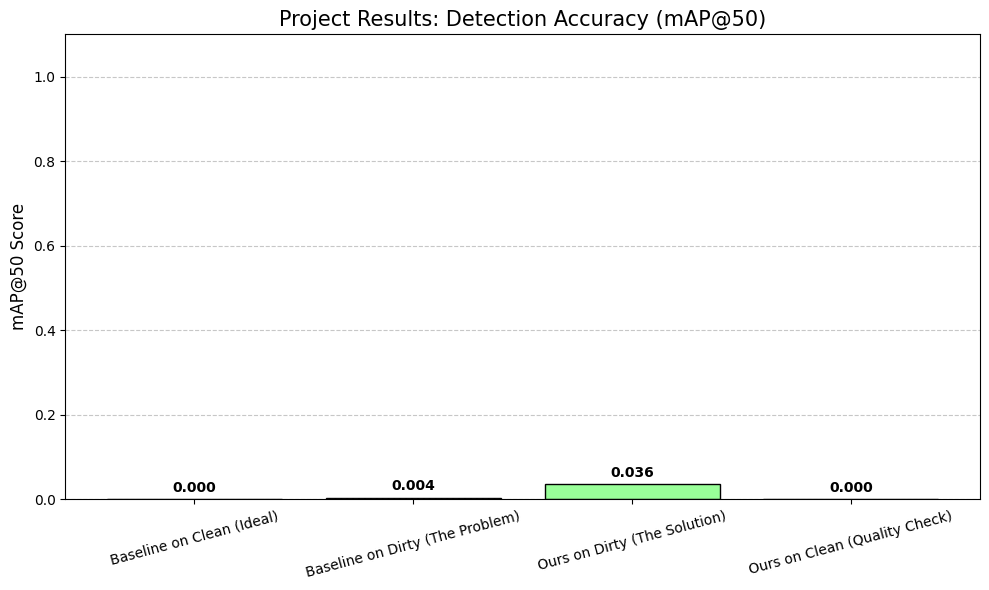

In [10]:
# יצירת DataFrame לסיכום התוצאות
results_data = {
    "Scenario": [
        "Baseline on Clean (Ideal)",
        "Baseline on Dirty (The Problem)",
        "Ours on Dirty (The Solution)",
        "Ours on Clean (Quality Check)"
    ],
    "mAP@50": [
        map_base_clean,
        map_base_dirty,
        map_trained_dirty,
        map_trained_clean
    ]
}

df_results = pd.DataFrame(results_data)

# חישוב KPIs ספציפיים למצגת
performance_drop = map_base_clean - map_base_dirty
improvement = map_trained_dirty - map_base_dirty
impact_on_clean = map_base_clean - map_trained_clean # אם חיובי, הייתה ירידה

print("\n" + "="*40)
print("   RESULTS SUMMARY FOR PRESENTATION")
print("="*40)
print(df_results)
print("-" * 40)
print(f"📉 Performance Drop (Clean -> Dirty): {performance_drop:.4f} (This is what needs fixing)")
print(f"🚀 Improvement after Fine-Tuning:     +{improvement:.4f} (Our contribution)")
print(f"🛡️ Impact on Clean Data Quality:      -{impact_on_clean:.4f} (Closer to 0 is better)")
print("="*40)

# ויזואליזציה (גרף עמודות למצגת)
plt.figure(figsize=(10, 6))
colors = ['lightgray', '#ff9999', '#99ff99', '#66b3ff'] # אפור, אדום, ירוק, כחול
bars = plt.bar(df_results["Scenario"], df_results["mAP@50"], color=colors, edgecolor='black')

# הוספת הערכים על העמודות
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.title("Project Results: Detection Accuracy (mAP@50)", fontsize=15)
plt.ylabel("mAP@50 Score", fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Displaying Training Metrics (Loss & Accuracy over Epochs):


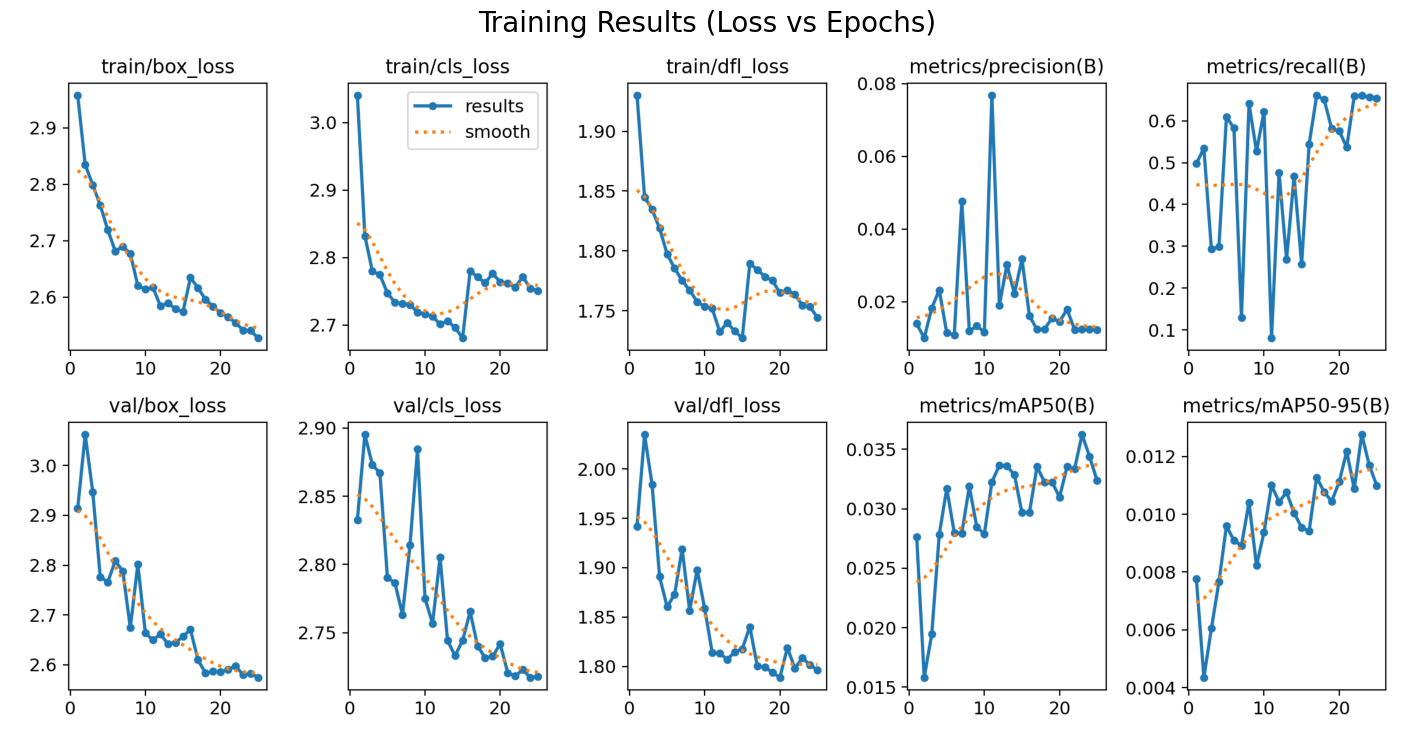


Displaying Confusion Matrix:


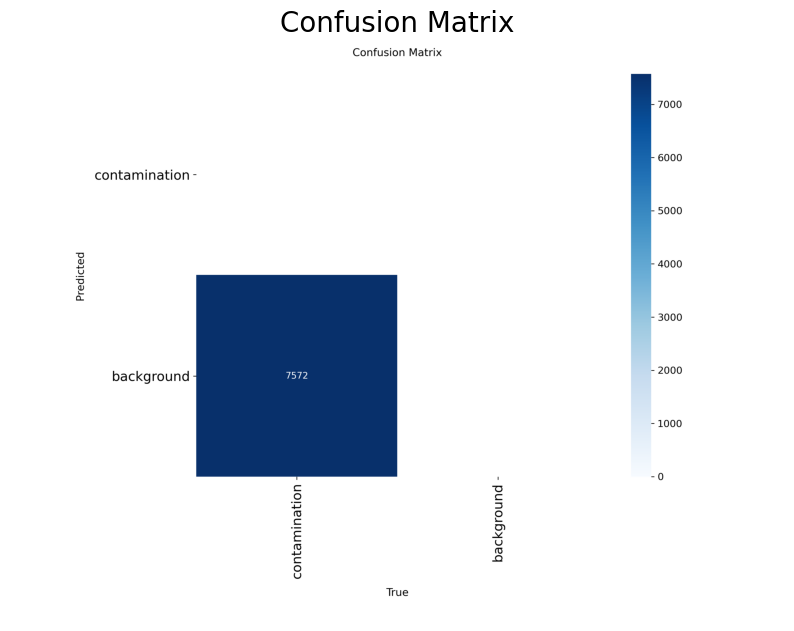

In [11]:
# הצגת גרפי האימון ש-YOLO יצר אוטומטית
results_path = os.path.join(trained_model.trainer.save_dir, 'results.png')
confusion_matrix_path = os.path.join(trained_model.trainer.save_dir, 'confusion_matrix.png')

print("Displaying Training Metrics (Loss & Accuracy over Epochs):")
if os.path.exists(results_path):
    plt.figure(figsize=(18, 10))
    img = Image.open(results_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title("Training Results (Loss vs Epochs)", fontsize=20)
    plt.show()
else:
    print("Results image not found.")

print("\nDisplaying Confusion Matrix:")
if os.path.exists(confusion_matrix_path):
    plt.figure(figsize=(10, 8))
    img = Image.open(confusion_matrix_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title("Confusion Matrix", fontsize=20)
    plt.show()
else:
    print("Confusion Matrix image not found.")

In [ ]:
import shutil
import os

# 1. מציאת קובץ המשקולות הטוב ביותר מהאימון האחרון
# מכיוון שקראנו לאימון "dirt_detection_trained", זה אמור להיות שם
source_best_model = os.path.join(output_dir, "..", "runs", "detect", "dirt_detection_trained", "weights", "best.pt")

# נתיב מתוקן (לפעמים YOLO שומר בנתיב יחסי לתיקיית העבודה הנוכחית)
if not os.path.exists(source_best_model):
    # ננסה למצוא את זה בתיקיית העבודה הנוכחית
    source_best_model = os.path.join(os.getcwd(), "runs", "detect", "dirt_detection_trained", "weights", "best.pt")

# 2. היעד: נשמור אותו בתיקייה הראשית של הפרויקט בשם ברור
destination_model = os.path.join(base_project_path, "my_final_dirt_model.pt")

# 3. העתקה
if os.path.exists(source_best_model):
    shutil.copy(source_best_model, destination_model)
    print(f"✅ Success! Model saved safely at:\n{destination_model}")
    print("Next time, you don't need to train. Just load this file!")
else:
    print(f"⚠️ Could not find the model at {source_best_model}. Check your 'runs' folder manually.")